In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from numpy import pi

PATH = os.getcwd()
print(PATH + '/')
print(os.listdir(PATH))

/home/andre/Documents/Git/FOCYou/Simulacao/
['bldc.py', 'bldc.ipynb', '.ipynb_checkpoints', 'README.md', 'simulatio.py', '__pycache__']


In [2]:
def back_emf_trapezoidal(theta):
    """
    Back-EMF trapezoidal normalizada (-1 a +1).
    theta em radianos.
    """

    theta = np.mod(theta, 2*np.pi)

    if theta < np.pi/6:
        return 6*theta/np.pi

    elif theta < 5*np.pi/6:
        return 1.0

    elif theta < 7*np.pi/6:
        return 1 - 6*(theta-5*np.pi/6)/np.pi

    elif theta < 11*np.pi/6:
        return -1.0

    else:
        return -1 + 6*(theta-11*np.pi/6)/np.pi

# Dados do motor

In [3]:
# Resistencia de armadura
Rs = 1 #Ohm

# Indutancia de magnetizacao
L = 5e-3 #H

# Constantes eletricas e mecanicas
Ke = 5e-2
Kt = Ke

# Torque da carga
Tl = 0.1

# Coeficiente de amortecimento
B = 1e-4

# Momento de inercia
J = 1e-3

# Frequencia da rede
# fs = 60 #Hz
# omega_s = 2*pi*fs #rad/s

# Quantidade de Polos no motor
POLOS = 4
PARES_DE_POLOS = POLOS / 2

# Amplitude da rede
Vm = 12 #V

# Defasagens das fases
PHI_A = 0
PHI_B = -2*pi/3
PHI_C = 2*pi/3

# Tensoes de fase
# Va = V*np.sin(we*time + PHI_A)
# Vb = V*np.sin(we*time + PHI_B)
# Vc = V*np.sin(we*time + PHI_C)

# Variáveis de simulação

In [4]:
TEMPO_MAX = 0.5     # s
dt = 1e-5         # s

time = np.arange(0, TEMPO_MAX, dt)
N = len(time)

# Simulação em malha aberta

In [5]:
theta_r = np.zeros(N)
omega_r = np.zeros(N)

ia = np.zeros(N)
ib = np.zeros(N)
ic = np.zeros(N)

Te = np.zeros(N)

Va = np.zeros(N)
Vb = np.zeros(N)
Vc = np.zeros(N)

ea = np.zeros(N)
eb = np.zeros(N)
ec = np.zeros(N)

for k in range(N-1):

    # Ângulo e velocidade elétrica do rotor
    theta_e = PARES_DE_POLOS * theta_r[k]

    # Tensões trifásicas da alimentação
    Va[k] = Vm * np.sin(theta_e  + PHI_A)
    Vb[k] = Vm * np.sin(theta_e  + PHI_B)
    Vc[k] = Vm * np.sin(theta_e  + PHI_C)

    # Back-EMF
    ea[k] = Ke * omega_r[k] * np.sin(theta_e + PHI_A)
    eb[k] = Ke * omega_r[k] * np.sin(theta_e + PHI_B)
    ec[k] = Ke * omega_r[k] * np.sin(theta_e + PHI_C)

    # ea[k] = Ke*omega_r[k]*back_emf_trapezoidal(theta_e + PHI_A)
    # eb[k] = Ke*omega_r[k]*back_emf_trapezoidal(theta_e + PHI_B)
    # ec[k] = Ke*omega_r[k]*back_emf_trapezoidal(theta_e + PHI_C)
    
    # Derivadas das correntes
    dia = (Va[k] - Rs * ia[k] - ea[k]) / L
    dib = (Vb[k] - Rs * ib[k] - eb[k]) / L
    dic = (Vc[k] - Rs * ic[k] - ec[k]) / L

    # Integração (Euler)
    ia[k+1] = ia[k] + dia * dt
    ib[k+1] = ib[k] + dib * dt
    ic[k+1] = ic[k] + dic * dt

    # Torque eletromagnético
    Te[k] = Kt * (
        ia[k] * np.sin(theta_e + PHI_A) +
        ib[k] * np.sin(theta_e + PHI_B) +
        ic[k] * np.sin(theta_e + PHI_C)
    )

    # Dinâmica mecânica
    domega = (Te[k] - Tl - B * omega_r[k]) / J

    omega_r[k+1] = omega_r[k] + domega * dt
    theta_r[k+1] = theta_r[k] + omega_r[k+1] * dt

# Gráficos da simulção de malha aberta

## Tensões

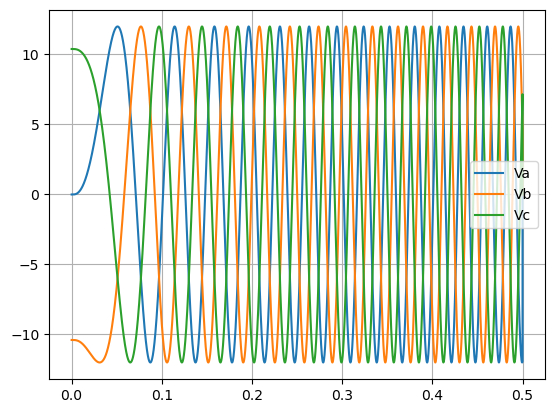

In [6]:
plt.plot(time, Va, label="Va")
plt.plot(time, Vb, label="Vb")
plt.plot(time, Vc, label="Vc")

plt.grid()
plt.legend()

plt.show()

# Correntes

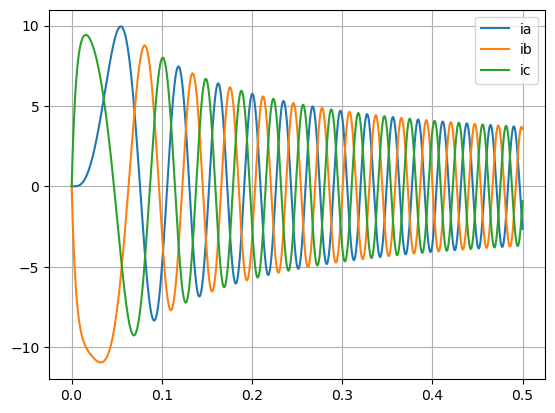

In [7]:
plt.plot(time, ia, label="ia")
plt.plot(time, ib, label="ib")
plt.plot(time, ic, label="ic")

plt.grid()
plt.legend()

plt.show()



## Velocidade

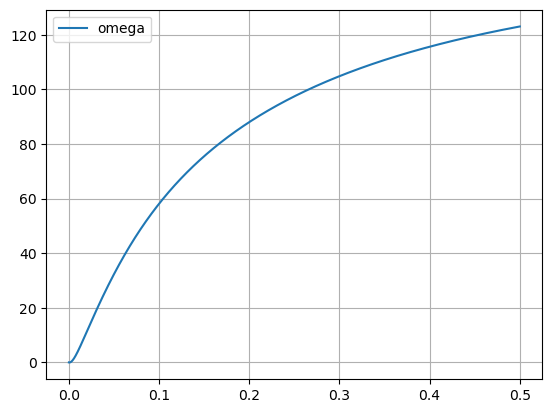

In [8]:
plt.plot(time,omega_r, label='omega')

plt.grid()
plt.legend()

plt.show()

## Torque

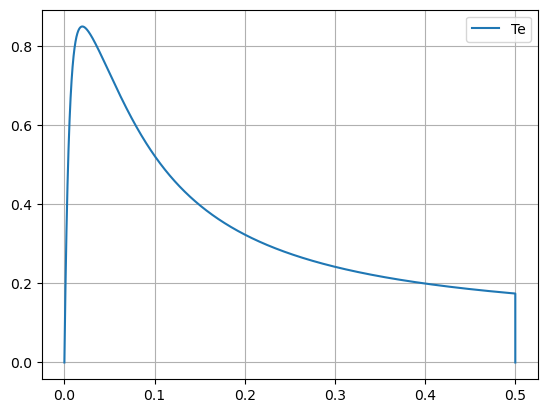

In [9]:
plt.plot(time, Te, label="Te")

plt.grid()
plt.legend()

plt.show()

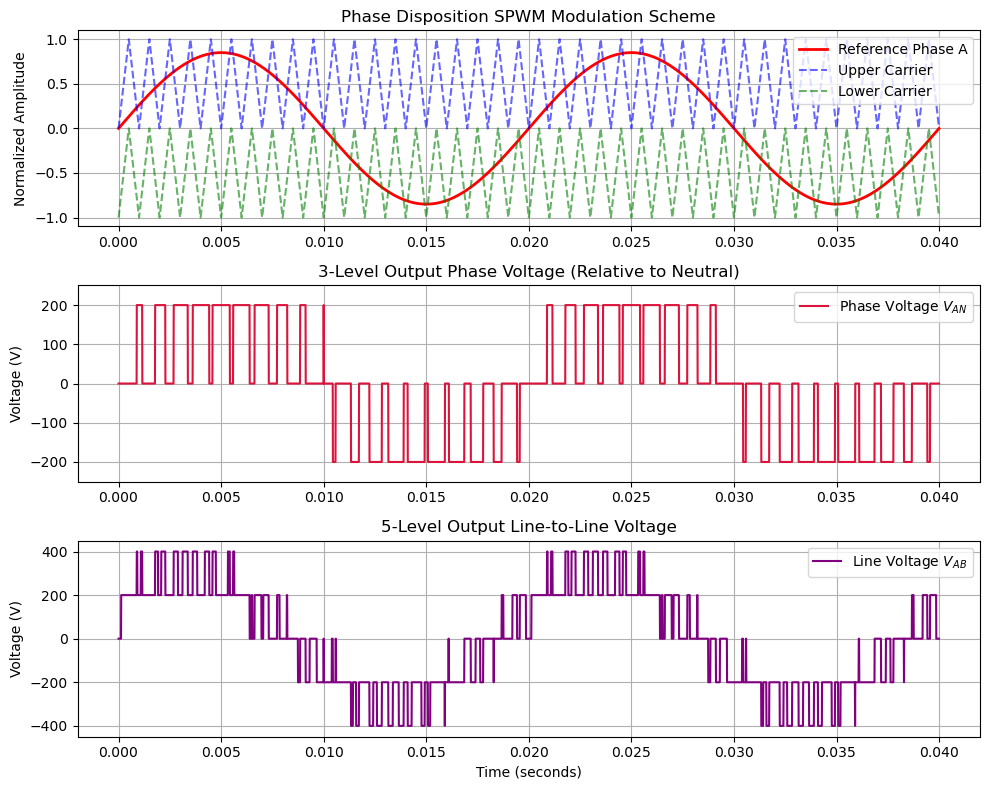

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. System Parameters
f_fundamental = 50        # Fundamental frequency (Hz)
f_carrier = 1000          # Switching/carrier frequency (Hz)
V_dc = 400                # Total DC link voltage (Volts)
m_a = 0.85                # Modulation index (0.0 to 1.0)

# 2. Time Array Generation
t_end = 0.04              # Simulate 2 complete fundamental cycles
fs = 200000               # Sampling frequency for clean visualization (Hz)
t = np.arange(0, t_end, 1/fs)

# 3. Reference Waveforms (120-degree phase shifts)
V_ref_A = m_a * np.sin(2 * np.pi * f_fundamental * t)
V_ref_B = m_a * np.sin(2 * np.pi * f_fundamental * t - 2 * np.pi / 3)
V_ref_C = m_a * np.sin(2 * np.pi * f_fundamental * t + 2 * np.pi / 3)

# 4. Phase Disposition (PD) High/Low Triangular Carriers
# Generate standard triangle wave bounded between [-1, 1]
raw_carrier = 2 * np.abs(2 * (t * f_carrier - np.floor(t * f_carrier + 0.5))) - 1
carrier_upper = (raw_carrier + 1) / 2       # Shifted to [0, 1]
carrier_lower = (raw_carrier - 1) / 2       # Shifted to [-1, 0]

# 5. Multilevel Logic Function
def compute_pole_voltage(v_ref, c_up, c_low, v_dc):
    # Output arrays default to 0 state
    v_pole = np.zeros_like(v_ref)
    # State mapping conditions
    v_pole[v_ref > c_up] = v_dc / 2
    v_pole[v_ref < c_low] = -v_dc / 2
    return v_pole

# 6. Compute Phase-to-Neutral Pole Voltages
V_AN = compute_pole_voltage(V_ref_A, carrier_upper, carrier_lower, V_dc)
V_BN = compute_pole_voltage(V_ref_B, carrier_upper, carrier_lower, V_dc)
V_CN = compute_pole_voltage(V_ref_C, carrier_upper, carrier_lower, V_dc)

# 7. Compute Line-to-Line Voltages (5 levels)
V_AB = V_AN - V_BN

# 8. Visualization Engineering
plt.figure(figsize=(10, 8))

# Subplot 1: Modulation Modulation Strategy (Reference vs Carriers)
plt.subplot(3, 1, 1)
plt.plot(t, V_ref_A, 'r', label='Reference Phase A', linewidth=2)
plt.plot(t, carrier_upper, 'b--', label='Upper Carrier', alpha=0.6)
plt.plot(t, carrier_lower, 'g--', label='Lower Carrier', alpha=0.6)
plt.title('Phase Disposition SPWM Modulation Scheme')
plt.ylabel('Normalized Amplitude')
plt.grid(True)
plt.legend(loc='upper right')

# Subplot 2: 3-Level Phase-to-Neutral Voltage Output
plt.subplot(3, 1, 2)
plt.plot(t, V_AN, 'crimson', label='Phase Voltage $V_{AN}$')
plt.title('3-Level Output Phase Voltage (Relative to Neutral)')
plt.ylabel('Voltage (V)')
plt.ylim(-V_dc/2 - 50, V_dc/2 + 50)
plt.grid(True)
plt.legend(loc='upper right')

# Subplot 3: 5-Level Line-to-Line Voltage Output
plt.subplot(3, 1, 3)
plt.plot(t, V_AB, 'purple', label='Line Voltage $V_{AB}$')
plt.title('5-Level Output Line-to-Line Voltage')
plt.xlabel('Time (seconds)')
plt.ylabel('Voltage (V)')
plt.ylim(-V_dc - 50, V_dc + 50)
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


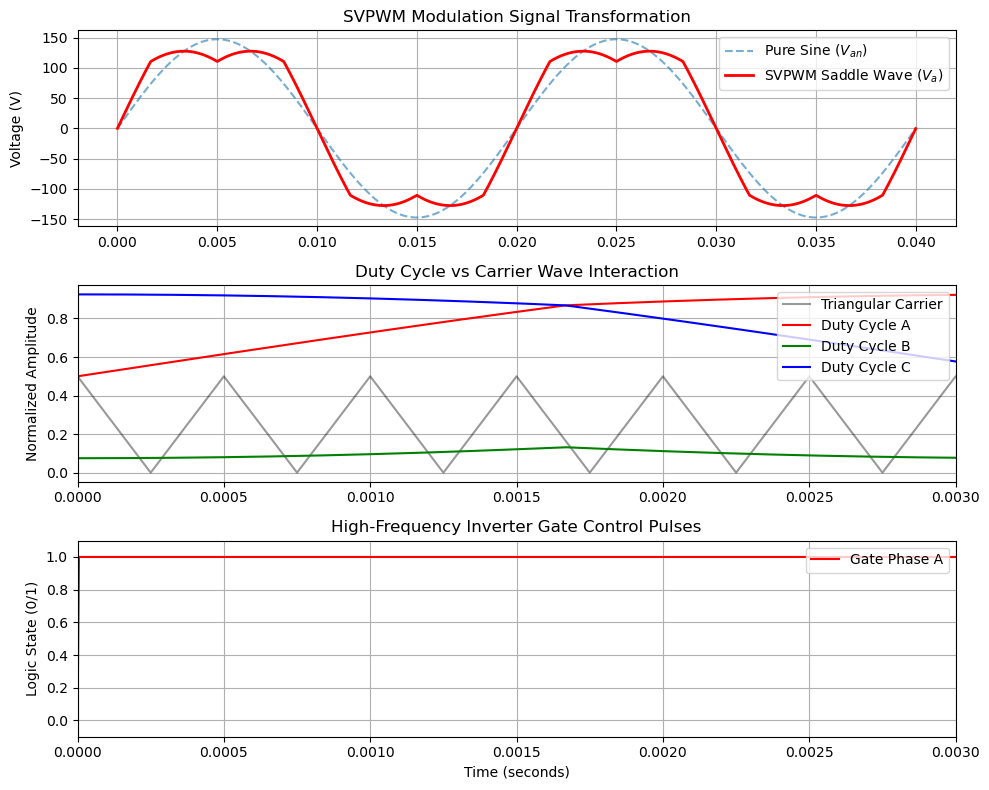

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Simulation Parameter Definitions ---
f_fundamental = 50.0   # Fundamental output frequency in Hz
f_carrier = 2000.0     # Switching frequency in Hz
V_dc = 300.0           # DC Bus Voltage in Volts
m_i = 0.85             # Modulation index (0.0 to 1.0)
t_end = 0.04           # Simulation time window (2 complete cycles)

# Time vectors
fs_sim = 200000.0      # High sampling rate for smooth visualization
t = np.arange(0, t_end, 1/fs_sim)

# --- 2. Reference Voltage Signal Generation ---
# Amplitudes matching modulation index
V_max_linear = V_dc / np.sqrt(3)  # Maximum linear phase voltage radius
V_amp = m_i * V_max_linear

# Generate balanced 3-phase sinusoidal reference voltages
V_a_ref = V_amp * np.sin(2 * np.pi * f_fundamental * t)
V_b_ref = V_amp * np.sin(2 * np.pi * f_fundamental * t - 2 * np.pi / 3)
V_c_ref = V_amp * np.sin(2 * np.pi * f_fundamental * t + 2 * np.pi / 3)

# --- 3. Common-Mode Voltage (Min-Max) Injection ---
# Extracting instantaneous min and max values across the 3 phases
V_max_instant = np.maximum(V_a_ref, np.maximum(V_b_ref, V_c_ref))
V_min_instant = np.minimum(V_a_ref, np.minimum(V_b_ref, V_c_ref))

# Midpoint allocation shifts zero sequence component
V_zero_sequence = -0.5 * (V_max_instant + V_min_instant)

# Inject common-mode voltage to generate the classic SVPWM saddle profile
V_a_svpwm = V_a_ref + V_zero_sequence
V_b_svpwm = V_b_ref + V_zero_sequence
V_c_svpwm = V_c_ref + V_zero_sequence

# --- 4. Duty Cycle & Gate Pulse Calculations ---
# Convert modulated voltage waveforms into duty cycles scaled from 0.0 to 1.0
Duty_A = (V_a_svpwm / V_dc) + 0.5
Duty_B = (V_b_svpwm / V_dc) + 0.5
Duty_C = (V_c_svpwm / V_dc) + 0.5

# Generate high-frequency triangular carrier wave
carrier = 0.5 + 0.5 * (2 * np.abs((t * f_carrier) % 1.0 - 0.5) - 1.0)

# Compare modulation signals against carrier to output digital gate pulses
Gate_A = (Duty_A > carrier).astype(float)
Gate_B = (Duty_B > carrier).astype(float)
Gate_C = (Duty_C > carrier).astype(float)

# --- 5. Interactive Visualization ---
plt.figure(figsize=(10, 8))

# Subplot 1: Transformation from Pure Sine Waves to SVPWM Saddle Profile
plt.subplot(3, 1, 1)
plt.plot(t, V_a_ref, '--', label='Pure Sine ($V_{an}$)', alpha=0.6)
plt.plot(t, V_a_svpwm, 'r-', linewidth=2, label='SVPWM Saddle Wave ($V_a$)')
plt.title('SVPWM Modulation Signal Transformation')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.legend(loc='upper right')

# Subplot 2: Duty Cycle Intersection with Triangular Carrier Wave
plt.subplot(3, 1, 2)
plt.plot(t, carrier, 'k', alpha=0.4, label='Triangular Carrier')
plt.plot(t, Duty_A, 'r', label='Duty Cycle A')
plt.plot(t, Duty_B, 'g', label='Duty Cycle B')
plt.plot(t, Duty_C, 'b', label='Duty Cycle C')
plt.title('Duty Cycle vs Carrier Wave Interaction')
plt.ylabel('Normalized Amplitude')
plt.xlim(0, 0.003)  # Zoomed view window to observe switching actions
plt.grid(True)
plt.legend(loc='upper right')

# Subplot 3: Resulting Inverter Digital Logic Gate Outputs
plt.subplot(3, 1, 3)
plt.plot(t, Gate_A, 'r', label='Gate Phase A')
plt.title('High-Frequency Inverter Gate Control Pulses')
plt.xlabel('Time (seconds)')
plt.ylabel('Logic State (0/1)')
plt.ylim(-0.1, 1.1)
plt.xlim(0, 0.003)  # Identical zoom matching carrier interaction
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()
